In [1]:
from agnpy.emission_regions.mod import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import synchrotron_cone
import numpy as np
from astropy.constants import c, sigma_T, m_e, e
#e = e.gauss
import matplotlib.pyplot as plt

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [2]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o = (3.63 * 1e-5 * u.T).to(u.G)
R_o = ( 7.32 * 1e13 * u.m ).to(u.cm)
L = (1e19 * u.m).to(u.cm)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = (5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_maximum = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
"""The normalization parameter is left to default, eq (7) in C. & P. leads to norm = 0? since alpha = 2"""
n_e = ExpCutoffPowerLaw(k=10, p = p, gamma_min = 0.1*gamma_minimum, gamma_max= 100*gamma_maximum, gamma_c= gamma_maximum )

In [3]:
jet = Cone(B_o = B_o, R_o = R_o , L = L, theta = theta_open, Gamma=Gamma, n_e = n_e,x_size=500,gamma_e_size=500, z =z)
jet.set_delta_D(Gamma=Gamma,theta_s = theta_s)

# Plots 
- Electron energy density as a function of x
- Total electrons as a function of gamma
- 
- Electron energy density vs Magnetic energy density: Proxy for Equipartition parameter

*Things to note:*
- Electron density decays as 1/R(x)^2, as expected due to the geometrical dilution included in the evolution equation. 
- Number of electrons stay constant as a function of x, due to the inclusion of geometrical dilution. This makes more physical sense, as the electrons only cool radiatively to shift to lower energies. Overall, should remain constant.
- Number of electrons drop linearly first, and then exponentially (@ γ>1e3) as a function of gamma, due to a exponential cut-off power law assumption of initial electron distribution
- Number of electrons vs energy at a particular x: Same distribution for any x above x=0?
- Equipartition: Starts at 1 and remains constant @ 1.2 throughout
- Magnetic and Electron energy density drop off as the inverse of radius squared, geometrical dilution

In [4]:
# Data
data = [
(575439.9373371543, 7.692946554041625e+45),
(1180320.6356517298, 3.6753441641809446e+45),
(2421029.04673618, 1.8950291465743076e+45),
(5861381.645140285, 8.435148160601475e+44),
(14454397.70745931, 3.481142923888426e+44),
(46989410.860521704, 1.1534180805525196e+44),
(147231250.24327165, 3.8169973137017866e+43),
(831763771.1026742, 6.485157528062233e+42),
(3076096814.7407174, 1.1725707943387419e+42),
(10964781961.43192, 7.858944800779638e+40),
(28575905433.749672, 1.2244668158998756e+39),
(59703528658.38415, 2.0753248803736612e+36),
(89536476554.96011, 4.373153302721358e+33),
(129419584144.9997, 1.4766294411828247e+30),
(109647819614.31963, 7.740013565615246e+31),
(39084089579.24041, 1.164019524379192e+38),
(18030177408.59577, 1.2817831835790027e+40),
(5445026528.424242, 4.4349366153056454e+41),
(1614358556.8264935, 2.865619626947542e+42),
(325087297.38543606, 1.693846972334023e+43),
(23768402.866248783, 2.075324880373661e+44)
]

# Split into x and y
x_ = [d[0] for d in data]
y_ = [d[1] for d in data]



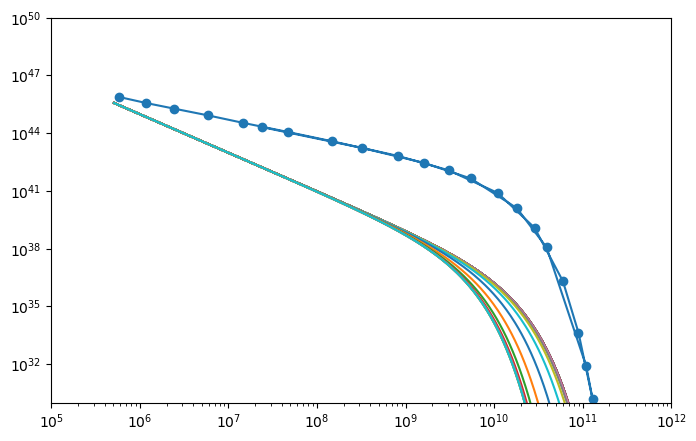

In [5]:
plt.figure(figsize=(8,5))
for i, _n_e_g in enumerate(jet.N_e_xg[::10]):
    plt.loglog((mec2*jet.gamma_e).to('eV'), 3*1e10*_n_e_g, label=f"x={i}")
plt.loglog(x_, y_, marker='o')
#plt.plot((mec2*jet.gamma_e).to('eV'), jet.norm_equi*3*1e10*jet.N_e_base)
#plt.legend()
plt.xlim(1e5,1e12)
plt.ylim(1e30,1e50)
plt.show()

/var/folders/6l/rfzttlkj3rgb82b10q8sd89m0000gn/T/ipykernel_47795/902684124.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


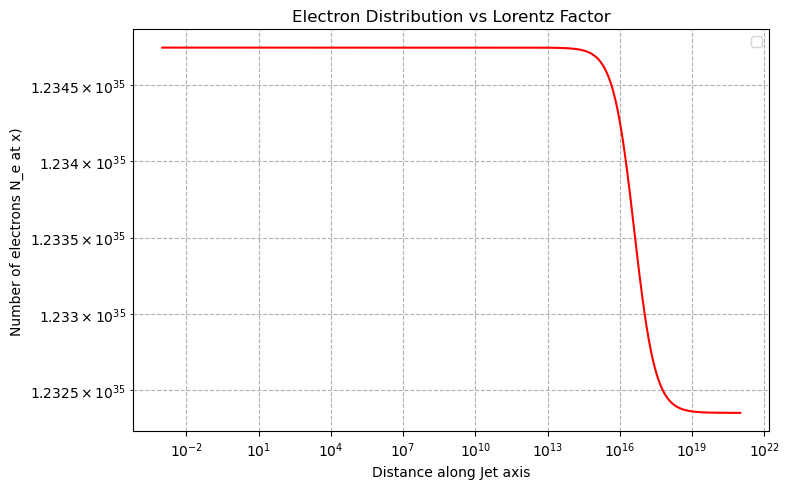

In [6]:
#Total number of electrons vs Lorentz factor 
plt.figure(figsize=(8,5))
plt.loglog(jet.x, jet.N_e_x, color = 'red')
plt.xlabel("Distance along Jet axis")
plt.ylabel("Number of electrons N_e at x)")
plt.title("Electron Distribution vs Lorentz Factor")
plt.grid(True, which='both', ls='--')
#plt.xlim(10,1e4)
#plt.ylim(130,1e40)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/6l/rfzttlkj3rgb82b10q8sd89m0000gn/T/ipykernel_47795/3900904298.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


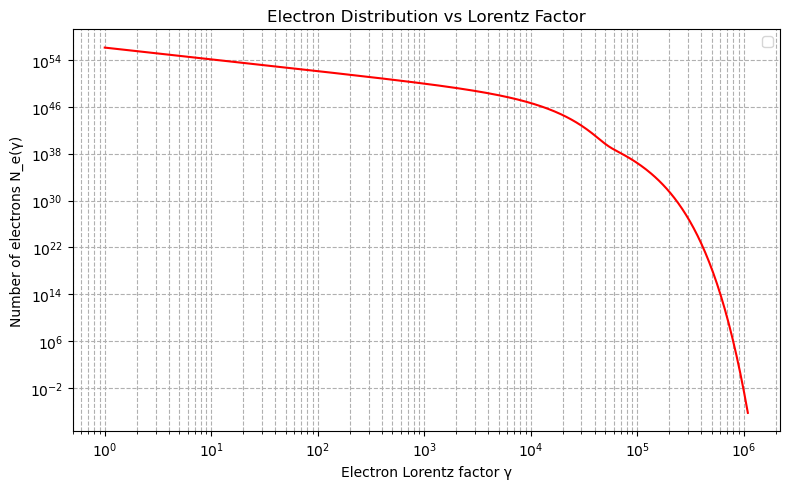

In [7]:
#Total number of electrons vs Lorentz factor 
plt.figure(figsize=(8,5))
plt.loglog(jet.gamma_e, jet.N_e_gamma, color = 'red')
plt.xlabel("Electron Lorentz factor γ")
plt.ylabel("Number of electrons N_e(γ)")
plt.title("Electron Distribution vs Lorentz Factor")
plt.grid(True, which='both', ls='--')
#plt.xlim(10,1e4)
plt.tight_layout()
plt.legend()
plt.show()

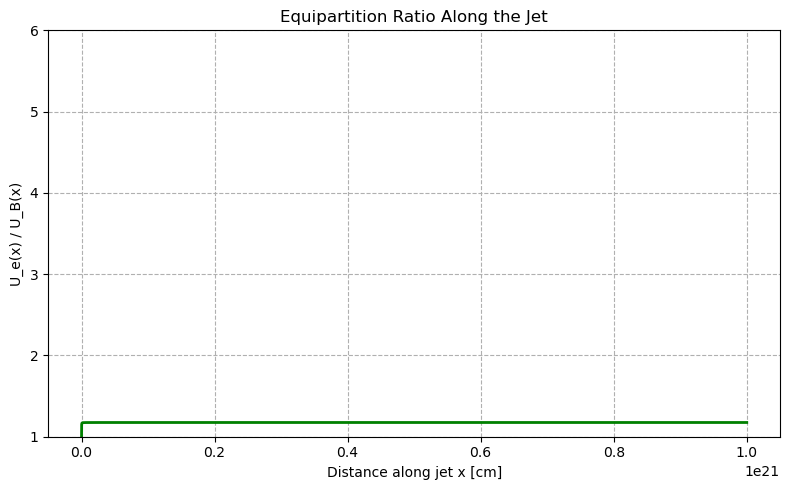

In [8]:
#Total number of electrons vs Lorentz factor 
plt.figure(figsize=(8,5))
plt.plot(jet.x, (jet.U_b_x / jet.U_e_x), color='green', lw=2)
plt.xlabel("Distance along jet x [cm]")
plt.ylabel("U_e(x) / U_B(x)")
plt.title("Equipartition Ratio Along the Jet")
plt.xscale('linear')
plt.yscale('linear')
plt.grid(True, which='both', ls='--')
plt.ylim(1,6)
plt.tight_layout()
plt.show()

# Validating Dermer formula with Cotter and Potter's Formula
Integrating Dermer's equation for Synchrotron power across frequencies to check if it matches with Cotter and Potter's formula for Synchrotron power


In [9]:
from agnpy.synchrotron.sync_mod import Synchrotron

/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/sync_mod.py:65: SyntaxWarning: invalid escape sequence '\k'
  """


In [10]:
nu_obs = np.logspace(3, 20, 1000) * u.Hz

# Dermer's Appraoch vs Cotter's Approach
Comparison between Synchrotron Power integrated over all frequencies. P_total_cotter overestimates by a little due to the assumption of all frequencies emitted at a particular frequency making the edges a bit sharper, compared to Dermer's Approach

In [11]:
#Dermer's Method
syn = Synchrotron(jet,nu_obs, ssa=True)

In [12]:
flux = syn.flux_obs(nu_obs)

In [13]:
syn.evaluate_attenuation()

<Quantity [6.64008619e-19, 7.08838887e-19, 7.56696426e-19, 8.07785716e-19,
           8.62325053e-19, 9.20547485e-19, 9.82701808e-19, 1.04905363e-18,
           1.11988652e-18, 1.19550319e-18, 1.27622683e-18, 1.36240248e-18,
           1.45439847e-18, 1.55260807e-18, 1.65745110e-18, 1.76937578e-18,
           1.88886063e-18, 2.01641651e-18, 2.15258884e-18, 2.29795991e-18,
           2.45315137e-18, 2.61882693e-18, 2.79569517e-18, 2.98451260e-18,
           3.18608689e-18, 3.40128035e-18, 3.63101361e-18, 3.87626958e-18,
           4.13809766e-18, 4.41761827e-18, 4.71602762e-18, 5.03460287e-18,
           5.37470759e-18, 5.73779767e-18, 6.12542749e-18, 6.53925668e-18,
           6.98105719e-18, 7.45272095e-18, 7.95626795e-18, 8.49385499e-18,
           9.06778489e-18, 9.68051645e-18, 1.03346750e-17, 1.10330636e-17,
           1.17786754e-17, 1.25747062e-17, 1.34245684e-17, 1.43319055e-17,
           1.53006080e-17, 1.63348303e-17, 1.74390082e-17, 1.86178782e-17,
           1.98764981e-17

In [14]:
sed_no_ssa = syn.sed_flux(nu_obs)

In [15]:
sed_ssa = syn.sed_flux(nu_obs, ssa=True)

In [16]:
#Cotter and Potter's Approach to Calculate P_sync over all frequencies
prefactor = (sigma_T.cgs * c.cgs) / (6*np.pi)
n = jet.N_e_xg
B = jet.B_x[:, None]
R = jet.R_x[:, None]
int_x = np.trapz(n * (B**2), jet.x,axis=0)
int_y = np.trapz(jet.gamma_e**2 * int_x, jet.gamma_e)
P_total_cotter = (prefactor * int_y)

# Total Jet Power
*Using the same parameters as used in Table 1 of Potter and Cotter; the total Jet power differs by 1 order of magnitude, why is this discrepancy?*

In [17]:
jet.P_total_jet.to('W')

<Quantity 7.04112694e+35 W>

# SED

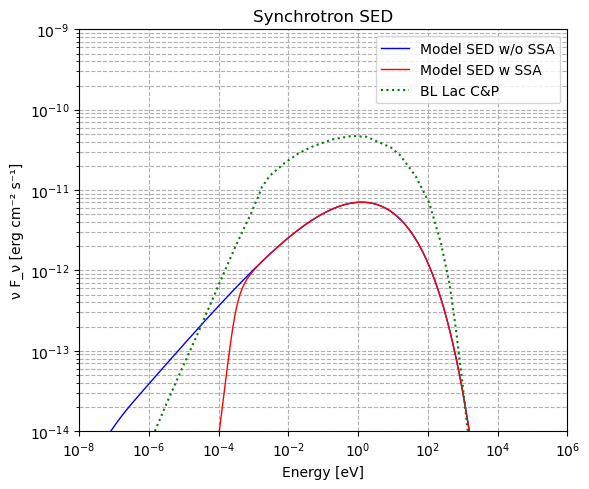

In [18]:
# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]

# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_no_ssa, color='blue', lw=1, label='Model SED w/o SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_cotter, color='green', lw=2, label='Model SED')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', lw=1, label='Model SED w SSA')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='dotted', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

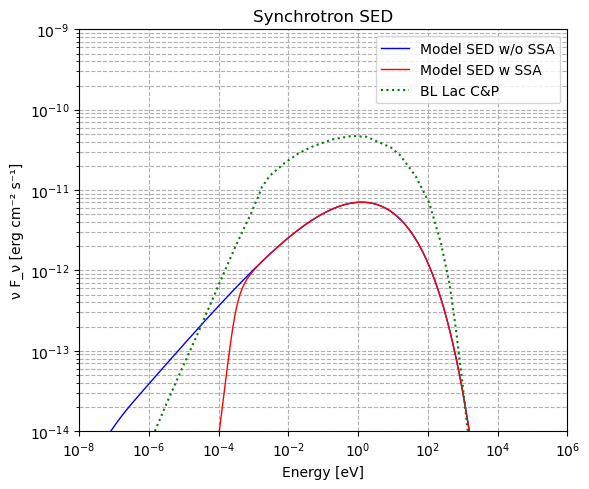

In [20]:
# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]

# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_no_ssa, color='blue', lw=1, label='Model SED w/o SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_cotter, color='green', lw=2, label='Model SED')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', lw=1, label='Model SED w SSA')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='dotted', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()